<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_and_gate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def laplacian(Z):
    return (
        -4 * Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    )

def make_and_fields(a=0, b=0, size=100):
    X = np.zeros((size, size), dtype=float)
    Y = np.zeros((size, size), dtype=float)

    # A створює речовину X
    if a == 1:
        X[45:55, 35:45] = 1.0

    # B створює речовину Y
    if b == 1:
        Y[45:55, 55:65] = 1.0

    return X, Y

In [2]:
def diffuse_and_gate(
    X,
    Y,
    steps=220,
    diffusion=0.20,
    decay=0.006,
    growth=1.50,
    output_decay=0.010
):
    X = X.copy()
    Y = Y.copy()
    Z = np.zeros_like(X)

    for _ in range(steps):
        # окремо дифундують два поля
        X = X + diffusion * laplacian(X) - decay * X
        Y = Y + diffusion * laplacian(Y) - decay * Y

        X = np.clip(X, 0, 1)
        Y = np.clip(Y, 0, 1)

        # AND-реакція: output росте тільки там, де X і Y перетнулись
        overlap = X * Y

        gate = np.zeros_like(X)
        gate[40:60, 40:60] = overlap[40:60, 40:60]

        Z = Z + diffusion * laplacian(Z) + growth * gate - output_decay * Z
        Z = np.clip(Z, 0, 1)

    return X, Y, Z


def detect_and_state(Z, a, b):
    total_mass = float(Z.sum())
    center_mass = float(Z[40:60, 40:60].sum())
    max_value = float(Z.max())

    if total_mass < 1.0:
        if a == 0 and b == 0:
            return "EMPTY"
        return "DECAY"

    if center_mass > 20.0 and max_value > 0.05:
        return "STABLE"

    return "DECAY"

A: 0 B: 0
STATE: EMPTY


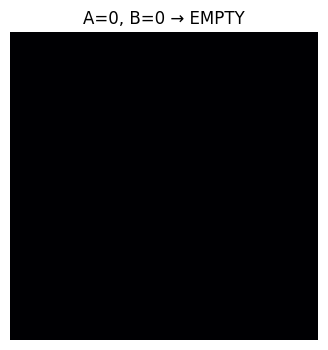

A: 1 B: 0
STATE: DECAY


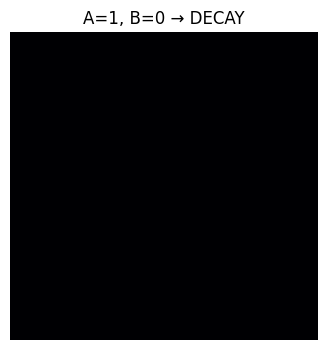

A: 0 B: 1
STATE: DECAY


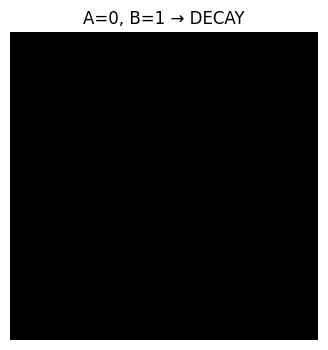

A: 1 B: 1
STATE: STABLE


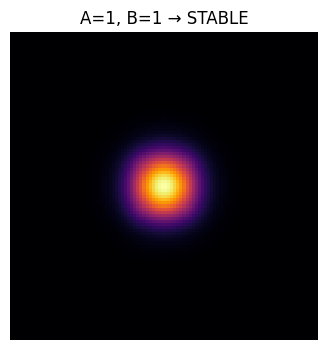

,A,B,state,output,mass,center,max
0,0,0,EMPTY,0,0.000,0.000,0.000
1,1,0,DECAY,0,0.000,0.000,0.000
2,0,1,DECAY,0,0.000,0.000,0.000
3,1,1,STABLE,1,43.375,29.978,0.126


In [3]:
cases = [(0, 0), (1, 0), (0, 1), (1, 1)]
results = []

for a, b in cases:
    X0, Y0 = make_and_fields(a, b)
    X, Y, Z = diffuse_and_gate(X0, Y0)
    state = detect_and_state(Z, a, b)

    results.append({
        "A": a,
        "B": b,
        "state": state,
        "output": 1 if state == "STABLE" else 0,
        "mass": round(float(Z.sum()), 3),
        "center": round(float(Z[40:60, 40:60].sum()), 3),
        "max": round(float(Z.max()), 3),
    })

    print("====================")
    print("A:", a, "B:", b)
    print("STATE:", state)

    plt.figure(figsize=(4, 4))
    plt.imshow(Z, cmap="inferno")
    plt.title(f"A={a}, B={b} → {state}")
    plt.axis("off")
    plt.show()

df = pd.DataFrame(results)
df